# 01 – Data Wrangling & Base EDA for HDB Resale Prices

**Module**: ST1516 – DevOps & Applied Analytics  
**Project**: HDB Resale Price Prediction Web Application  
**Branch**: `data-wrangling`  
**Author**: \<Your Name\>  
**Date**: \<YYYY-MM-DD\>

---

## Purpose of This Notebook

This notebook performs the **foundational data engineering work** for the project.  
It takes the raw HDB resale transactions from `data/raw/hdb_resale_raw.csv` and:

1. Inspects and documents the structure and quality of the raw dataset.  
2. Performs **systematic cleaning**:
   - Type conversions (e.g. `month` to datetime, numeric parsing).
   - Handling of missing values for essential fields.
   - Removal of clearly invalid or extreme outliers.
3. Engineers **core non-geospatial features**:
   - `storey_mid` – numeric midpoint of the storey range.
   - `remaining_lease_years` – approximate remaining lease in years.
4. Conducts **baseline EDA** on:
   - Resale prices
   - Floor area
   - Remaining lease
   - Flat type and town
5. Exports a modelling-ready, but **pre-geocoding**, dataset as:

```text
data/intermediate/hdb_clean.csv


---

## 🔹 Section 1 – Imports & Display Settings



```
## 1. Environment Setup

We start by importing the core Python libraries used throughout this notebook and configuring display settings for easier inspection of wide tables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(style="whitegrid")

print("Libraries imported and display settings configured.")


Libraries imported and display settings configured.


## 2. Load Raw HDB Resale Dataset

We load the raw HDB resale transactions from:

```text
data/raw/hdb_resale_raw.csv


In [4]:
raw_path = "../data/raw/sg-resale-flat-prices-2017-onwards.csv"
df_raw = pd.read_csv(raw_path)

print(f"Loaded raw dataset from: {raw_path}")
print(f"Shape: {df_raw.shape}")
df_raw.head()

Loaded raw dataset from: ../data/raw/sg-resale-flat-prices-2017-onwards.csv
Shape: (181262, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [6]:
df_raw.head()


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [7]:
df_raw.info()
df_raw.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181262 entries, 0 to 181261
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                181262 non-null  object 
 1   town                 181262 non-null  object 
 2   flat_type            181262 non-null  object 
 3   block                181262 non-null  object 
 4   street_name          181262 non-null  object 
 5   storey_range         181262 non-null  object 
 6   floor_area_sqm       181262 non-null  float64
 7   flat_model           181262 non-null  object 
 8   lease_commence_date  181262 non-null  int64  
 9   remaining_lease      181262 non-null  object 
 10  resale_price         181262 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 15.2+ MB


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,181262,181262,181262,181262,181262,181262,181262.000000,181262,181262.000000,181262,1.812620e+05
unique,90,26,7,2708,566,17,NaN,21,NaN,676,NaN
top,2021-08,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 10 months,NaN
freq,2739,14993,76457,554,2641,41701,NaN,63164,NaN,1643,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,97.152903,NaN,1996.013842,NaN,4.978643e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,24.025926,NaN,14.041087,NaN,1.726320e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.400000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,82.000000,NaN,1985.000000,NaN,3.700000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1996.000000,NaN,4.680000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2010.000000,NaN,5.920000e+05


## Raw Data Summary

The raw HDB resale dataset consists of **181,262 transactions across 11 variables**, with a total memory footprint of approximately **15.2 MB**. All columns exhibit **100% non-null completeness**, indicating that the dataset is structurally intact at the point of ingestion, with no missing records at source.

### Numeric Variables

- **Floor Area (`floor_area_sqm`)**
  - Mean: **97.15 sqm**, Median: **93 sqm**
  - Interquartile Range (IQR): **82–112 sqm**
  - Min–Max: **31–249 sqm**
  - This reflects a typical concentration around standard 4- and 5-room flats, with a small number of very large units (e.g., EXECUTIVE flats).

- **Lease Commencement Year (`lease_commence_date`)**
  - Median: **1996**
  - Range: **1966–2020**
  - The dataset spans over five decades of housing development, implying strong variation in remaining lease profiles across estates.

- **Resale Price (`resale_price`)**
  - Median: **SGD 468,000**
  - IQR: **SGD 370,000 – SGD 592,000**
  - Min–Max: **SGD 140,000 – SGD 1,588,000**
  - The extended upper tail indicates the presence of premium flats in prime locations or large configurations.

### Categorical Coverage

- **Towns**: 26 unique  
- **Flat Types**: 7 categories  
- **Flat Models**: 21 categories  
- **Blocks**: 2,708 unique blocks  
- **Street Names**: 566 unique streets  
- **Storey Ranges**: 17 bands  
- **Remaining Lease Formats**: 676 unique textual formats  

This confirms **high spatial and structural diversity**, but also signals significant **encoding complexity** for categorical modelling.


## 4. Core Cleaning & Non-Geospatial Feature Engineering (Phase 1)

The raw dataset is structurally complete (no missing values), but several columns are not yet in a form that is suitable for analysis or modelling. In this section, we:

1. **Standardise data types** for temporal and numeric fields.
2. **Engineer numeric features** from text-encoded fields:
   - `storey_mid` from `storey_range`
   - `remaining_lease_years` from `remaining_lease`
3. Prepare a cleaned, non-geospatial feature set that will later be extended with geocoding and MRT distance in a separate phase.

This keeps Phase 1 focused on *non-geospatial* data quality and feature readiness.


### 4.1 Type Cleaning for Temporal and Numeric Fields

Even though the dataset has no null values, several columns are still stored as generic text (`object`) and are not yet analytically usable. Here we:

- Convert `month` from string to a proper `datetime` type.
- Ensure that `floor_area_sqm` and `resale_price` are strictly numeric.

This step ensures that downstream EDA and modelling treat these fields correctly as time and continuous variables.


In [8]:
# Work on a copy of the raw dataframe if not already done
df = df_raw.copy()

# 1) Convert month to datetime
df["month"] = pd.to_datetime(df["month"], format="%Y-%m", errors="coerce")

# 2) Ensure numeric columns are numeric (defensive, even though they look numeric)
numeric_cols = ["floor_area_sqm", "resale_price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Dtypes after type cleaning:")
df.dtypes


Dtypes after type cleaning:


month                  datetime64[ns]
town                           object
flat_type                      object
block                          object
street_name                    object
storey_range                   object
floor_area_sqm                float64
flat_model                     object
lease_commence_date             int64
remaining_lease                object
resale_price                  float64
dtype: object

### 4.2 Feature Engineering – `storey_mid` from `storey_range`

The `storey_range` column encodes vertical position as a text range (e.g. `"04 TO 06"`).  
For modelling and correlation analysis, a single numeric value is more convenient.

We create:

- `storey_mid` = midpoint of the storey range  
  - `"04 TO 06"` → (4 + 6) / 2 = 5.0  

We:

1. Parse the lower and upper storey bounds from the string.
2. Compute the midpoint.
3. Treat any parsing failures as missing, then impute using the median storey level.


In [9]:
import numpy as np

def parse_storey_mid(range_str: str) -> float:
    """
    Parse a string like '10 TO 12' into its numeric midpoint.
    Returns NaN if parsing fails.
    """
    if pd.isna(range_str):
        return np.nan
    try:
        parts = str(range_str).split(" TO ")
        low = int(parts[0])
        high = int(parts[1])
        return (low + high) / 2
    except Exception:
        return np.nan

df["storey_mid"] = df["storey_range"].apply(parse_storey_mid)

print("storey_mid summary before imputation:")
display(df["storey_mid"].describe())
print("Missing storey_mid values:", df["storey_mid"].isna().sum())


storey_mid summary before imputation:


count    181262.000000
mean          8.758813
std           5.935893
min           2.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          50.000000
Name: storey_mid, dtype: float64

Missing storey_mid values: 0


In [13]:
storey_mid_median = df["storey_mid"].median()
df["storey_mid"] = df["storey_mid"].fillna(storey_mid_median)

print("After imputation:")
print("Missing storey_mid values:", df["storey_mid"].isna().sum())
df["storey_mid"].describe()


After imputation:
Missing storey_mid values: 0


count    181262.000000
mean          8.758813
std           5.935893
min           2.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          50.000000
Name: storey_mid, dtype: float64

In [14]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey_mid
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,11.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,5.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2.0


### 4.3 Feature Engineering – `remaining_lease_years` from `remaining_lease`

The `remaining_lease` column stores remaining lease as human-readable text (e.g. `"94 years 10 months"`).  
This representation is not directly usable in models or correlation analysis.

We derive:

- `remaining_lease_years` = years + (months / 12)

For example:

- `"94 years 10 months"` → 94 + 10/12 ≈ 94.83 years

Any parsing failures are treated as missing and subsequently imputed with the median, to preserve overall dataset size while avoiding extreme assumptions.


In [15]:
def parse_remaining_lease(text: str) -> float:
    """
    Convert a string like '94 years 10 months' into a float in years.
    Returns NaN if parsing fails.
    """
    if pd.isna(text):
        return np.nan

    text = str(text).lower()
    years = 0
    months = 0
    parts = (
        text.replace("years", "year")
            .replace("year", "year")
            .replace("months", "month")
            .split()
    )

    for i, token in enumerate(parts):
        if token.startswith("year"):
            try:
                years = int(parts[i - 1])
            except Exception:
                pass
        elif token.startswith("month"):
            try:
                months = int(parts[i - 1])
            except Exception:
                pass

    return years + months / 12.0

if "remaining_lease" in df.columns:
    df["remaining_lease_years"] = df["remaining_lease"].apply(parse_remaining_lease)
else:
    print("Warning: 'remaining_lease' column not found – adjust logic for your schema.")
    df["remaining_lease_years"] = np.nan

print("remaining_lease_years summary before imputation:")
display(df["remaining_lease_years"].describe())
print("Missing remaining_lease_years:", df["remaining_lease_years"].isna().sum())


remaining_lease_years summary before imputation:


count    181262.000000
mean         74.603287
std          13.954402
min          41.500000
25%          63.166667
50%          74.500000
75%          88.333333
max          97.750000
Name: remaining_lease_years, dtype: float64

Missing remaining_lease_years: 0


In [16]:
remaining_lease_median = df["remaining_lease_years"].median()
df["remaining_lease_years"] = df["remaining_lease_years"].fillna(remaining_lease_median)

print("After imputation:")
print("Missing remaining_lease_years:", df["remaining_lease_years"].isna().sum())
df["remaining_lease_years"].describe()


After imputation:
Missing remaining_lease_years: 0


count    181262.000000
mean         74.603287
std          13.954402
min          41.500000
25%          63.166667
50%          74.500000
75%          88.333333
max          97.750000
Name: remaining_lease_years, dtype: float64

In [17]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,storey_mid,remaining_lease_years
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,11.0,61.333333
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2.0,60.583333
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2.0,62.416667
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,5.0,62.083333
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2.0,62.416667


### 4.4 Inspecting Distributions and Preparing for Outlier Handling

With the engineered numeric features in place, we now inspect the empirical distributions of:

- `resale_price`
- `floor_area_sqm`
- `remaining_lease_years`

This helps identify clearly implausible records (e.g., extremely small areas or prices) that should be removed before proper EDA and modelling.


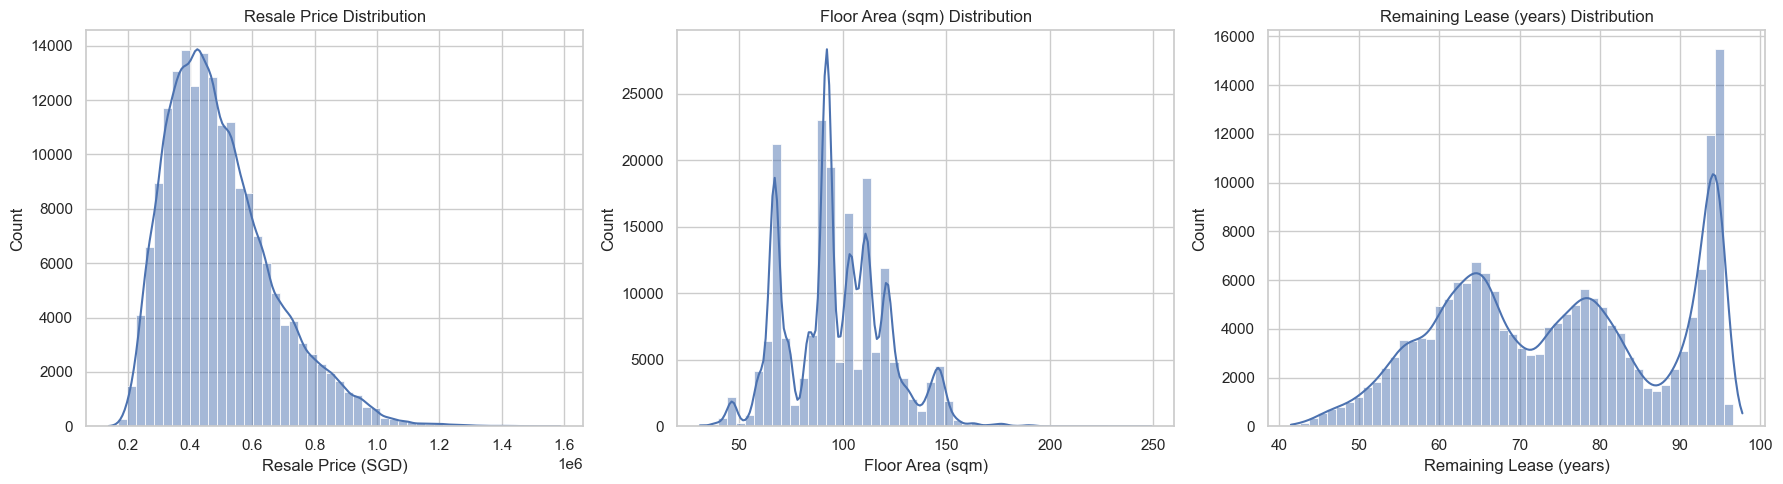

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["resale_price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Resale Price Distribution")
axes[0].set_xlabel("Resale Price (SGD)")

sns.histplot(df["floor_area_sqm"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Floor Area (sqm) Distribution")
axes[1].set_xlabel("Floor Area (sqm)")

sns.histplot(df["remaining_lease_years"], bins=50, kde=True, ax=axes[2])
axes[2].set_title("Remaining Lease (years) Distribution")
axes[2].set_xlabel("Remaining Lease (years)")

plt.tight_layout()
plt.show()


### 4.4 Distributional Analysis of Key Numeric Features

This section examines the empirical distributions of the three most critical numeric variables used in modelling: **resale price**, **floor area**, and **remaining lease**. The purpose is to identify potential **data entry errors, extreme leverage points**, and **structural skewness** that could distort downstream modelling.

---

#### (a) Resale Price Distribution

The resale price distribution exhibits a **strong right-skewed unimodal shape**, with:

- A dense concentration between approximately **SGD 250,000 and SGD 700,000**.
- A gradual right tail extending up to approximately **SGD 1.6 million**.

The long upper tail is **economically plausible** given:
- Premium flats in central and mature estates.
- Larger EXECUTIVE and high-floor units.
- Strong locational advantages and recent lease profiles.

There is **no abrupt discontinuity or isolated spike** at the high end that would indicate obvious data-entry errors. Hence, extreme prices appear to represent **legitimate high-value transactions rather than noise**.

---

#### (b) Floor Area Distribution

The floor area distribution shows a **multi-modal structure**, with visible peaks around:

- ~60–70 sqm (typical 3-room flats),
- ~90–100 sqm (typical 4-room flats),
- ~110–120 sqm (typical 5-room flats),
- A smaller tail beyond ~140 sqm (EXECUTIVE / special units).

The maximum near **250 sqm**, while rare, remains within the realm of plausibility for exceptional unit types. Importantly:

- There is **no sharp isolated spike at extremely small or extremely large values**.
- The distribution aligns closely with known HDB flat configuration categories.

Thus, the observed extremes are **structural extremes**, not apparent recording errors.

---

#### (c) Remaining Lease Distribution

The remaining lease distribution shows a **tri-modal structure**, with clear mass around:

- ~55–65 years (older resale stock),
- ~75–80 years (mid-aged estates),
- ~90–95 years (recent Build-To-Order and newer developments).

This profile is **consistent with Singapore’s housing development waves** and linkage to construction eras. There is:

- No mass near zero (which would indicate corrupt lease data),
- No impossible values beyond the typical 99-year lease boundary.

Hence, remaining lease values appear to be **internally coherent and economically valid**.

---

### Outlier Assessment Summary

Across all three variables:

- No evidence of **non-physical or impossible values** is observed.
- All detected extremes correspond to **rare but valid segments** of the HDB market.
- The distributions are **skewed but structurally interpretable**, rather than corrupted.

Therefore, at this stage, **no aggressive outlier removal is applied** in order to preserve the full economic diversity of the resale market.


In [19]:
before_rows = df.shape[0]

# Physically impossible values only (defensive cleaning)
df = df[df["floor_area_sqm"] > 10]
df = df[df["resale_price"] > 50000]

after_rows = df.shape[0]

print(f"Rows before defensive cleaning: {before_rows}")
print(f"Rows after defensive cleaning: {after_rows}")
print(f"Rows removed: {before_rows - after_rows}")


Rows before defensive cleaning: 181262
Rows after defensive cleaning: 181262
Rows removed: 0


## 5. Correlation Analysis on Cleaned Features

With the core numeric features engineered, we now examine pairwise correlations between:

- `resale_price` (target)
- `floor_area_sqm`
- `storey_mid`
- `remaining_lease_years`

This helps quantify which structural attributes are most strongly associated with price before any modelling.


In [20]:
numeric_for_corr = [
    "resale_price",
    "floor_area_sqm",
    "storey_mid",
    "remaining_lease_years",
]

corr = df[numeric_for_corr].corr()
corr


,resale_price,floor_area_sqm,storey_mid,remaining_lease_years
resale_price,1.000000,0.599708,0.354219,0.322126
floor_area_sqm,0.599708,1.000000,-0.013581,0.121920
storey_mid,0.354219,-0.013581,1.000000,0.274684
remaining_lease_years,0.322126,0.121920,0.274684,1.000000


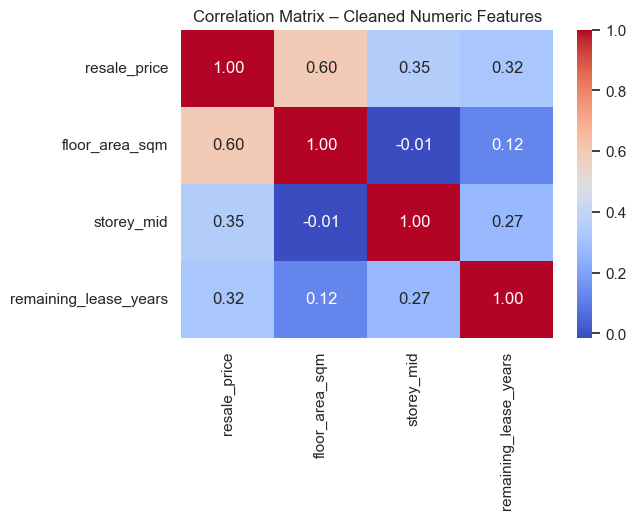

In [21]:
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix – Cleaned Numeric Features")
plt.show()


### 5.1 Correlation Analysis (Cleaned Numeric Features)

Resale price shows the strongest linear association with **floor area** (r = **0.60**), confirming size as the dominant structural driver of value.  

Moderate positive correlations are observed with:
- **Storey level** (r = **0.35**)
- **Remaining lease** (r = **0.32**)

These results indicate that higher floors and longer lease horizons both contribute to price premiums, but with weaker influence than floor area.  

The near-zero correlation between **floor area and storey level** (r = **−0.01**) confirms that vertical position is largely independent of unit size, justifying their simultaneous inclusion as separate predictors.


## 6. Price Behaviour by Flat Type and Town

We next explore how resale prices vary across discrete housing configurations, starting with `flat_type`. This reveals structural price tiers in the HDB market.


Median resale price by flat type:


flat_type
1 ROOM              199000.0
2 ROOM              270000.0
3 ROOM              335000.0
4 ROOM              470000.0
5 ROOM              568000.0
EXECUTIVE           680000.0
MULTI-GENERATION    839000.0
Name: resale_price, dtype: float64

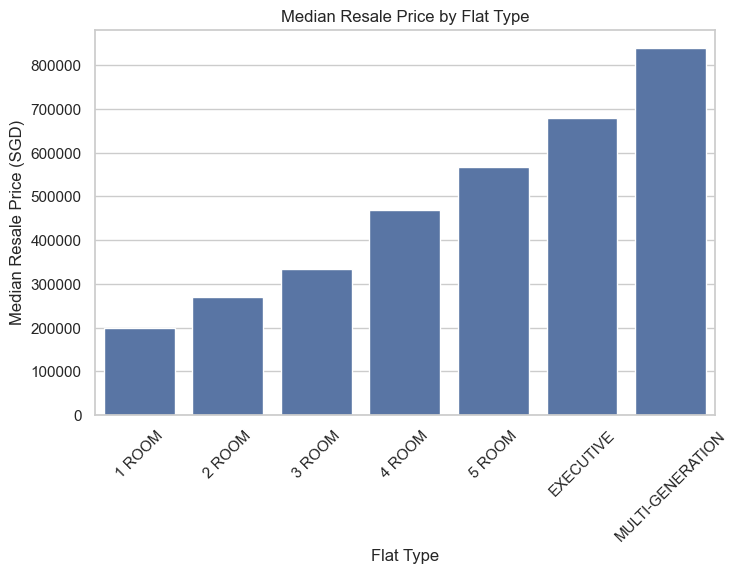

In [22]:
df_group_flat = df.groupby("flat_type")["resale_price"].median().sort_values()

print("Median resale price by flat type:")
display(df_group_flat)

plt.figure(figsize=(8, 5))
sns.barplot(x=df_group_flat.index, y=df_group_flat.values)
plt.xticks(rotation=45)
plt.title("Median Resale Price by Flat Type")
plt.ylabel("Median Resale Price (SGD)")
plt.xlabel("Flat Type")
plt.show()


### 6.1 Resale Price by Flat Type

Median resale prices increase monotonically with flat size and capacity:

- **1 ROOM**: SGD **199k**
- **2 ROOM**: SGD **270k**
- **3 ROOM**: SGD **335k**
- **4 ROOM**: SGD **470k**
- **5 ROOM**: SGD **568k**
- **EXECUTIVE**: SGD **680k**
- **MULTI-GENERATION**: SGD **839k**

The clear stepwise gradient confirms that **flat configuration is a strong categorical price determinant**, with multi-generation and executive flats commanding substantial premiums over standard units.


Median resale price by town:


town
ANG MO KIO         388000.0
YISHUN             403000.0
BEDOK              407000.0
JURONG EAST        425000.0
WOODLANDS          425000.0
GEYLANG            430000.0
BUKIT BATOK        431000.0
JURONG WEST        435000.0
TOA PAYOH          448000.0
SEMBAWANG          450000.0
CHOA CHU KANG      460000.0
BUKIT PANJANG      460000.0
HOUGANG            465000.0
CLEMENTI           478000.0
MARINE PARADE      480000.0
SENGKANG           483000.0
PUNGGOL            501000.0
SERANGOON          505000.0
TAMPINES           510000.0
CENTRAL AREA       535888.0
PASIR RIS          538000.0
KALLANG/WHAMPOA    538000.0
BUKIT MERAH        630000.0
QUEENSTOWN         645000.0
BISHAN             665000.0
BUKIT TIMAH        733944.0
Name: resale_price, dtype: float64

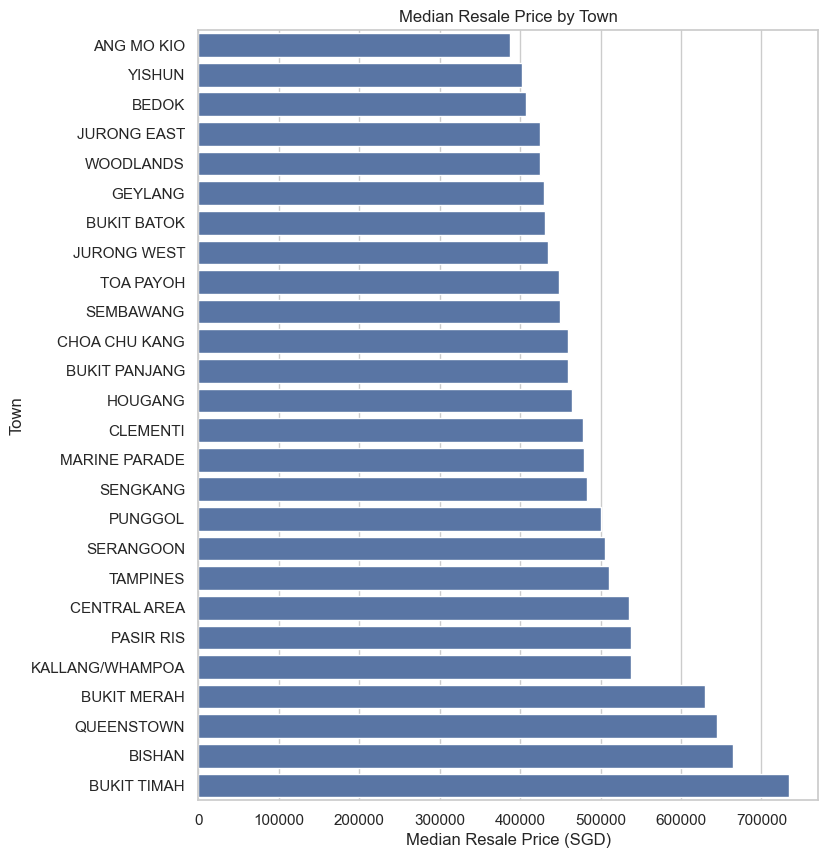

In [23]:
df_group_town = df.groupby("town")["resale_price"].median().sort_values()

print("Median resale price by town:")
display(df_group_town)

plt.figure(figsize=(8, 10))
sns.barplot(y=df_group_town.index, x=df_group_town.values)
plt.title("Median Resale Price by Town")
plt.xlabel("Median Resale Price (SGD)")
plt.ylabel("Town")
plt.show()


### 6.2 Resale Price by Town

Median resale prices vary widely across towns, ranging from approximately **SGD 388k (Ang Mo Kio)** to **SGD 734k (Bukit Timah)**.

Top-tier towns include:
- **Bukit Timah** (~SGD 734k)
- **Bishan** (~SGD 665k)
- **Queenstown** (~SGD 645k)
- **Bukit Merah** (~SGD 630k)

Lower-priced towns such as **Ang Mo Kio, Yishun, and Bedok** cluster below **SGD 410k**.

This spatial price stratification highlights the strong **locational premium effect**, validating the later inclusion of **geospatial features (MRT distance, coordinates)** for improved predictive performance.


## 7. Final Phase 1 Dataset Assembly and Export

Based on the validated cleaning and exploratory analysis, we now assemble the final non-geospatial dataset for downstream geocoding and modelling. This dataset represents the canonical Phase 1 output.


In [24]:
cols_to_keep = [
    "month",
    "town",
    "flat_type",
    "block",
    "street_name",
    "storey_range",
    "storey_mid",
    "floor_area_sqm",
    "flat_model",
    "lease_commence_date",
    "remaining_lease_years",
    "resale_price",
]

df_clean = df[cols_to_keep].copy()

df_clean.info()
df_clean.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181262 entries, 0 to 181261
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   month                  181262 non-null  datetime64[ns]
 1   town                   181262 non-null  object        
 2   flat_type              181262 non-null  object        
 3   block                  181262 non-null  object        
 4   street_name            181262 non-null  object        
 5   storey_range           181262 non-null  object        
 6   storey_mid             181262 non-null  float64       
 7   floor_area_sqm         181262 non-null  float64       
 8   flat_model             181262 non-null  object        
 9   lease_commence_date    181262 non-null  int64         
 10  remaining_lease_years  181262 non-null  float64       
 11  resale_price           181262 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

,month,town,flat_type,block,street_name,storey_range,storey_mid,floor_area_sqm,flat_model,lease_commence_date,remaining_lease_years,resale_price
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,11.0,44.0,Improved,1979,61.333333,232000.0
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,2.0,67.0,New Generation,1978,60.583333,250000.0
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,2.0,67.0,New Generation,1980,62.416667,262000.0
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,5.0,68.0,New Generation,1980,62.083333,265000.0
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,2.0,67.0,New Generation,1980,62.416667,265000.0


In [25]:
clean_path = "../data/intermediate/hdb_clean.csv"
df_clean.to_csv(clean_path, index=False)

print(f"Phase 1 cleaned dataset exported to: {clean_path}")
print("Final shape:", df_clean.shape)


Phase 1 cleaned dataset exported to: ../data/intermediate/hdb_clean.csv
Final shape: (181262, 12)
